# 01. Fetch Chikwawa District Boundaries

This notebook uses the OpenStreetMap (OSM) database to fetch the exact administrative boundary polygon for Chikwawa, Malawi.
We will save this polygon as a GeoJSON file. It acts as our Area of Interest (AOI) to filter all satellite data in the next steps so we only download relevant pixels.

Fetching administrative boundaries for: Chikwawa, Southern Region, Malawi...


<Axes: >

CRS (Coordinate Reference System): epsg:4326
Bounds:
        minx       miny      maxx       maxy
0  34.249141 -16.689351  35.12127 -15.741065

Success! Saved to ../data/raw/chikwawa_boundary.geojson


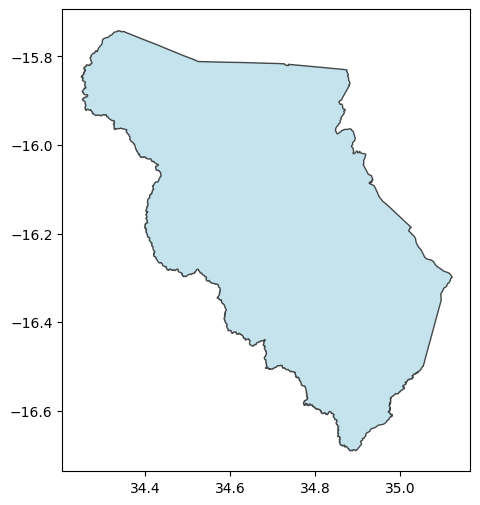

In [1]:
import osmnx as ox
import geopandas as gpd
import os

# Ensure raw data directory exists
os.makedirs("../data/raw", exist_ok=True)

# Define the location query for OSM
# This specifically targets the administrative boundary of Chikwawa
place_name = "Chikwawa, Southern Region, Malawi"

print(f"Fetching administrative boundaries for: {place_name}...")
try:
    # Get the polygon from OSM
    gdf = ox.geocode_to_gdf(place_name)
    
    # Plot the boundary to ensure it's correct
    display(gdf.plot(figsize=(6,6), color='lightblue', edgecolor='black', alpha=0.7))
    
    # Display some basic info
    print(f"CRS (Coordinate Reference System): {gdf.crs}")
    print(f"Bounds:\n{gdf.bounds}")
    
    # Save the boundary to our raw data folder as GeoJSON
    output_path = "../data/raw/chikwawa_boundary.geojson"
    gdf.to_file(output_path, driver='GeoJSON')
    print(f"\nSuccess! Saved to {output_path}")
except Exception as e:
    print("Error fetching data:", e)
    print("Tip: If OSM fails, we can adjust the place_name or download manually from HDX.")
